# Reading in Data

In [1]:
import pandas as pd

In [2]:
customers = pd.read_csv('SupermarketPurchase.csv')
customers.head()

,Cust_id,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION
0,1,300.000000,1200.00,4,0.00,11
1,2,2563.282500,41012.52,16,78737.48,2
2,4,3510.000000,7020.00,2,780.00,4
3,8,4530.000000,13590.00,3,1510.00,1
4,9,2428.076923,33455.00,15,17445.00,6


In [3]:
customers = customers.set_index('Cust_id')
customers.head()

,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION
Cust_id,,,,,
1,300.000000,1200.00,4,0.00,11
2,2563.282500,41012.52,16,78737.48,2
4,3510.000000,7020.00,2,780.00,4
8,4530.000000,13590.00,3,1510.00,1
9,2428.076923,33455.00,15,17445.00,6


In [4]:
customers.loc[31]

AVG_Actual_price_12             2100.0
Purchase_Value                  2100.0
No_of_Items                        1.0
Total_Discount                     0.0
MONTH_SINCE_LAST_TRANSACTION       3.0
Name: 31, dtype: float64

# How many Clusters?

In [5]:
# we need this next bit of code to stop a user warning in windows
import os
os.environ["OMP_NUM_THREADS"] = "1"

#import our library now  as usual
from sklearn.cluster import KMeans

#create models with 1-15 clusters
for n in range(1,16):
    KMeans(n_clusters = n).fit(customers)

In [6]:
inertias = []

for n in range(1,16):
    model = KMeans(n_clusters = n).fit(customers)
    
    # appending the inertia to a list
    inertias.append(model.inertia_)

In [7]:
inertias

[3236693428896.6323,
 1224767172518.4426,
 805561829383.3785,
 542455791492.20526,
 460328835505.4166,
 382639527270.8958,
 314765201953.4828,
 307312609268.8809,
 237730810337.08337,
 199822619607.9516,
 165667472528.70633,
 155518041223.7281,
 150349767033.23834,
 118274754202.10866,
 107075345510.54301]

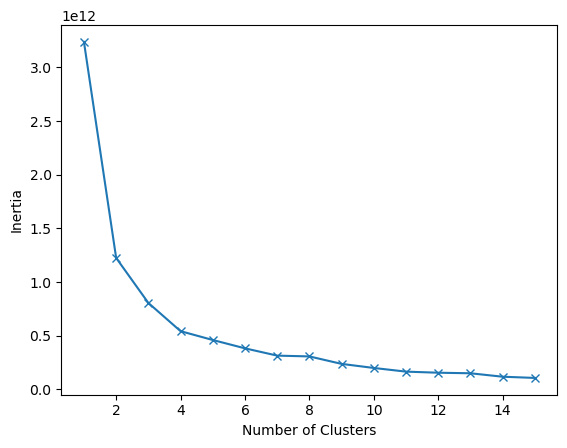

In [8]:
# importing required library
import matplotlib.pyplot as plt

# plotting x-axis from 1 to 15, inertias on y-axis and usind 'X-', to mark the points
plt.plot(range(1,16), inertias, 'x-' )
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show();

In [9]:
customers['3-cluster'] = KMeans(
    n_clusters=3,
    random_state=13
).fit(customers).labels_

customers['4-cluster'] = KMeans(
    n_clusters=4,
    random_state=13
).fit(customers).labels_

In [10]:
customers.groupby('3-cluster').count()

,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION,4-cluster
3-cluster,,,,,,
0,677,677,677,677,677,677
1,6,6,6,6,6,6
2,19,19,19,19,19,19


In [11]:
customers.groupby('4-cluster').count()

,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION,3-cluster
4-cluster,,,,,,
0,572,572,572,572,572,572
1,6,6,6,6,6,6
2,19,19,19,19,19,19
3,105,105,105,105,105,105


In [12]:
customers.groupby(['3-cluster','4-cluster']).count()

AVG_Actual_price_12  Purchase_Value  No_of_Items  \
3-cluster 4-cluster                                                     
0         0                          572             572          572   
          3                          105             105          105   
1         1                            6               6            6   
2         2                           19              19           19   

                     Total_Discount  MONTH_SINCE_LAST_TRANSACTION  
3-cluster 4-cluster                                                
0         0                     572                           572  
          3                     105                           105  
1         1                       6                             6  
2         2                      19                            19

# Analysing the clusters

In [13]:
# Filter to only clusters 0 and 3
customers_without_outliers = customers[(customers['4-cluster']==0) | (customers['4-cluster']==3)]

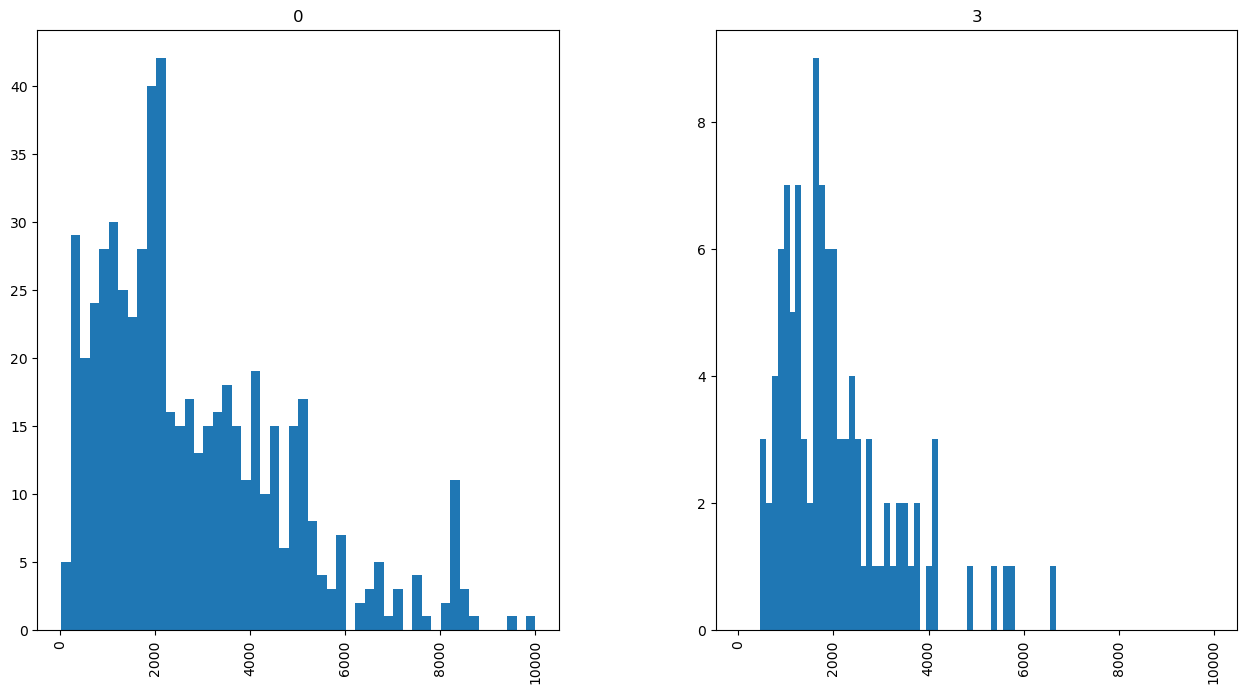

In [17]:
customers_without_outliers['AVG_Actual_price_12'].hist( # Make histograms of AVG_Actual_price_12
    by = customers_without_outliers['4-cluster'], # Make one for each cluster for comparison
    sharex = True, # The figures should have the same x axis
    sharey = False, # The figures should not have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

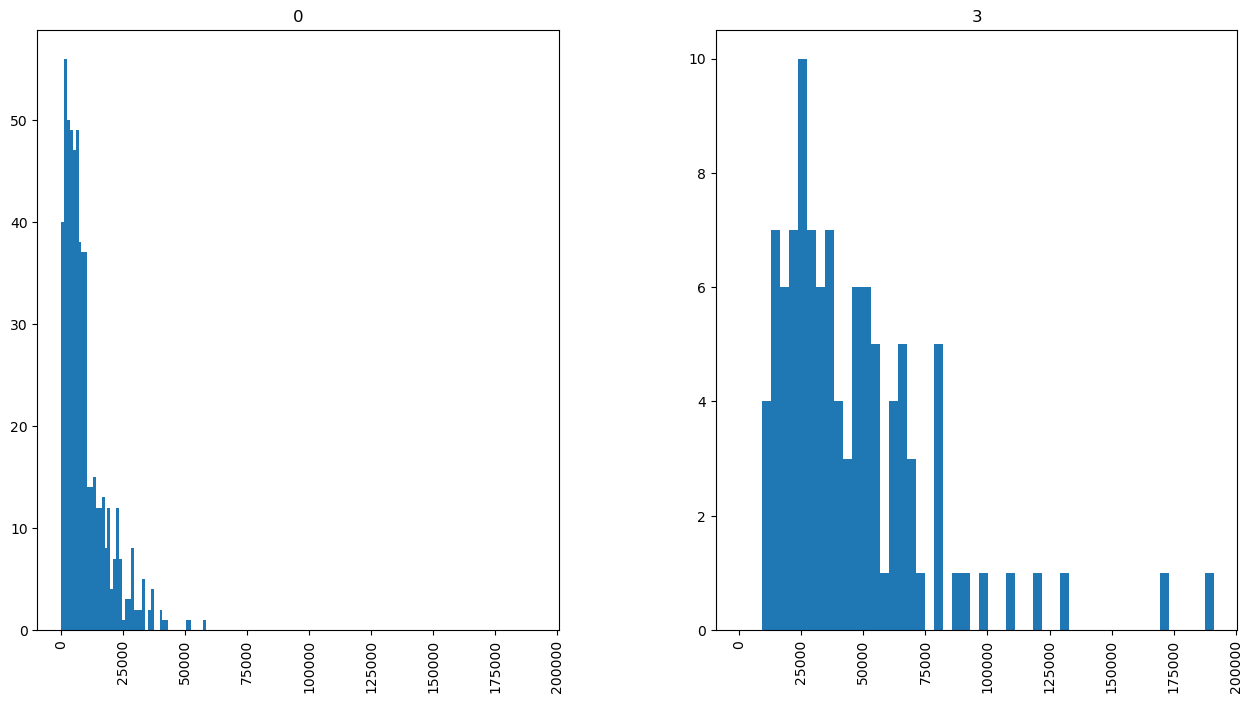

In [18]:
customers_without_outliers['Purchase_Value'].hist(
    by = customers_without_outliers['4-cluster'],
    sharex = True, # The figures should have the same x axis
    sharey = False, # The figures should not have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

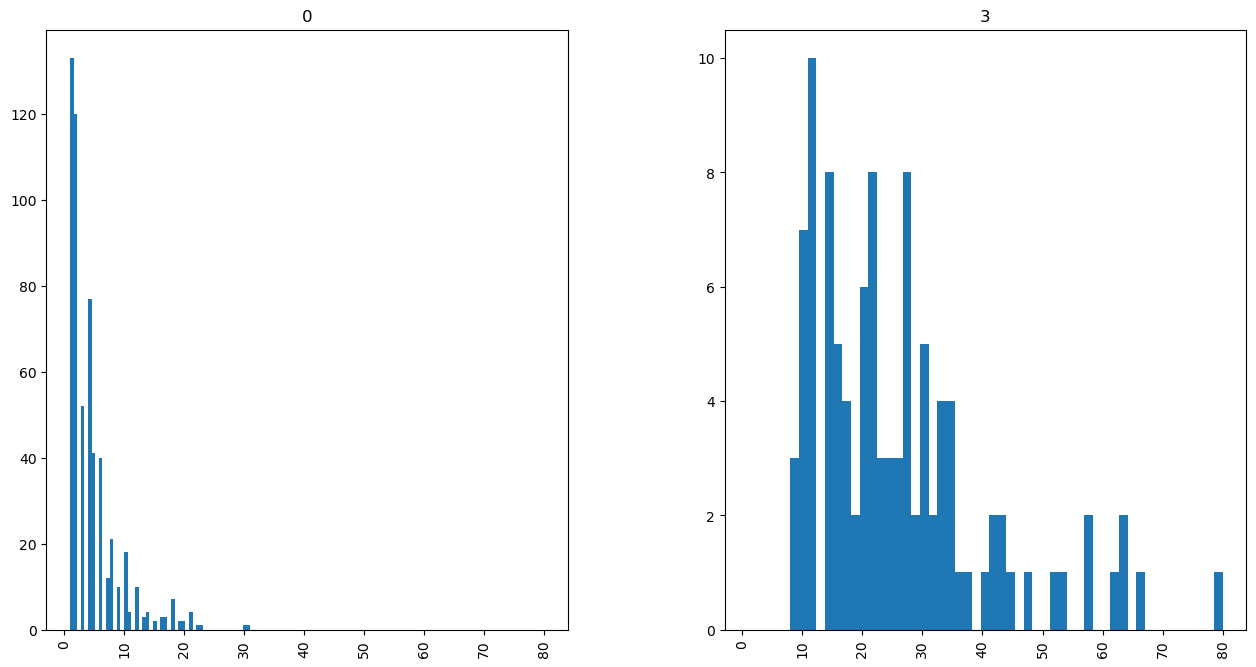

In [19]:
customers_without_outliers['No_of_Items'].hist(
    by = customers_without_outliers['4-cluster'],
    sharex = True, # The figures should have the same x axis
    sharey = False, # The figures should not have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

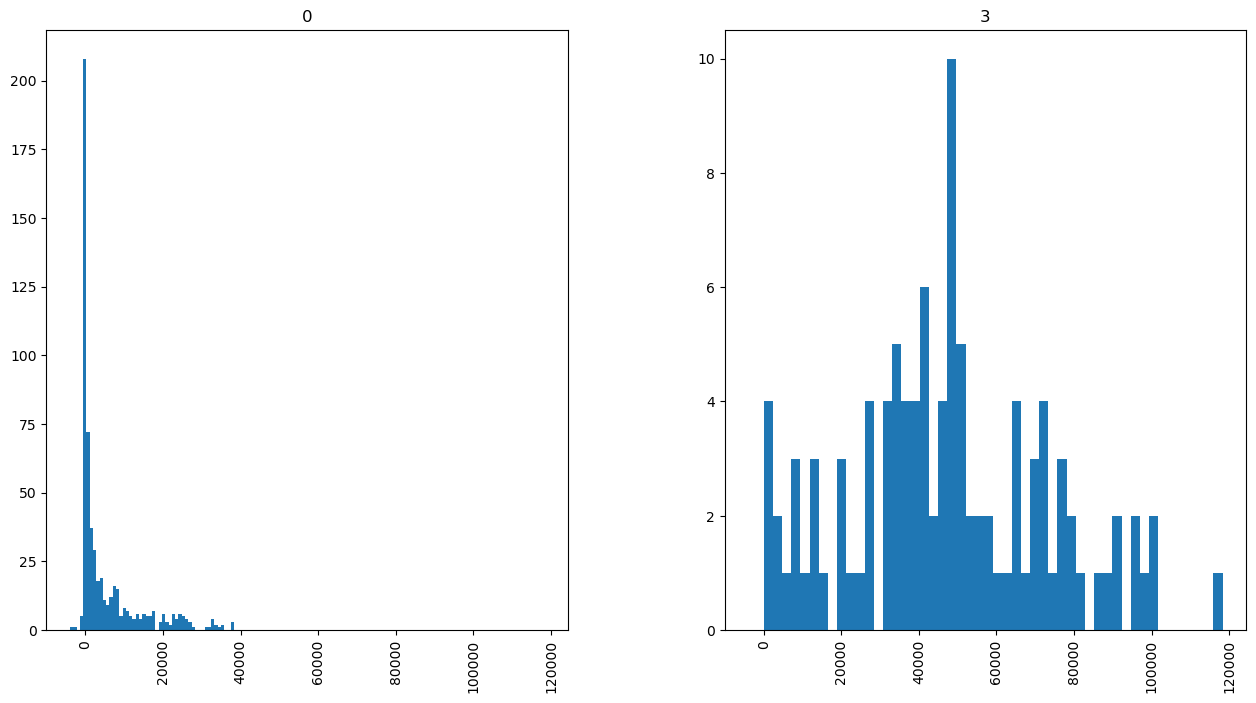

In [20]:
customers_without_outliers['Total_Discount'].hist(
    by = customers_without_outliers['4-cluster'],
    sharex = True, # The figures should have the same x axis
    sharey = False, # The figures should not have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

In [57]:
Cluster_mapping = {0: 'normal', 
                   1: 'outlier', 
                   2: 'outlier', 
                   3: 'bulk'}

customers['Cluster'] = customers['4-cluster'].map(Cluster_mapping)
customers.head()

,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION,3-cluster,4-cluster,Cluster
Cust_id,,,,,,,,
1,300.000000,1200.00,4,0.00,11,0,0,normal
2,2563.282500,41012.52,16,78737.48,2,0,3,bulk
4,3510.000000,7020.00,2,780.00,4,0,0,normal
8,4530.000000,13590.00,3,1510.00,1,0,0,normal
9,2428.076923,33455.00,15,17445.00,6,0,0,normal


# Making a Prediction

In [60]:
customers[customers['Cluster'] == 'bulk'].mean(numeric_only=True)

AVG_Actual_price_12              2069.465339
Purchase_Value                  45597.336857
No_of_Items                        25.857143
Total_Discount                  47338.796476
MONTH_SINCE_LAST_TRANSACTION        2.961905
3-cluster                           0.000000
4-cluster                           3.000000
dtype: float64

In [61]:
customers[customers['Cluster'] == 'normal'].mean(numeric_only=True)

AVG_Actual_price_12             2788.683813
Purchase_Value                  9631.684458
No_of_Items                        4.520979
Total_Discount                  5297.638969
MONTH_SINCE_LAST_TRANSACTION       5.552448
3-cluster                          0.000000
4-cluster                          0.000000
dtype: float64

In [62]:
customers = customers[customers['Cluster'] != 'outlier']

# Testing a prediction

In [64]:
Cluster_mapping = {
    'bulk': 45597.336857,
    'normal': 9631.684458
}
customers.loc[:, 'Next_purchase_value'] = customers['Cluster'].map(Cluster_mapping)
customers.head()

,AVG_Actual_price_12,Purchase_Value,No_of_Items,Total_Discount,MONTH_SINCE_LAST_TRANSACTION,3-cluster,4-cluster,Cluster,Next_purchase_value
Cust_id,,,,,,,,,
1,300.000000,1200.00,4,0.00,11,0,0,normal,9631.684458
2,2563.282500,41012.52,16,78737.48,2,0,3,bulk,45597.336857
4,3510.000000,7020.00,2,780.00,4,0,0,normal,9631.684458
8,4530.000000,13590.00,3,1510.00,1,0,0,normal,9631.684458
9,2428.076923,33455.00,15,17445.00,6,0,0,normal,9631.684458


In [68]:
from sklearn.metrics import r2_score
r2_score(customers['Purchase_Value'], customers['Next_purchase_value'])

0.4412350321261066